In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys, os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import OrderedDict
from statsmodels.stats.multitest import fdrcorrection, multipletests

from utils.config import FREQ_BANDS, ATLAS_PATH
from utils.io.io_atlas import load_atlas
from utils.io.io_results import load_fc_combined_data
from utils.analysis.functional_connectivity.fc_compute import bin_fcs_by_freq
from utils.analysis.functional_connectivity.fc_aggregate_network import aggregate_to_network_fc
from utils.analysis.functional_connectivity.fc_strength import compute_network_strength_df
from utils.analysis.functional_connectivity.fc_statistical_analysis import (
    networkpair_permtest,
    summarize_network_differences,
    compare_band_to_whole_network,
    compute_slow_network_drivers,
    get_network_edges,
    test_network_level,
    print_network_overview,
)
from utils.plot.plot_statistical_analysis import plot_network_edges

# --- Load combined FCs ---
RES_DIR = "/cluster/home/herminea/mental_health_project/workspace/results/fmri_prep/vlmd/combined_fc"

In [3]:
DIR = "/cluster/home/herminea/mental_health_project/workspace/results/fmri_prep/mvmd/imfs_new"
print("DIR contains number of files:", len(os.listdir(DIR)))

DIR contains number of files: 165


#### Prep for Statistical Analysis

In [4]:
### Load FC combined data
subjects_combined, fcs_by_imf, groups, freqs_by_imf = load_fc_combined_data(RES_DIR)

### Bin FCs by frequency bands
freq_bands_fc = {k: v for k, v in FREQ_BANDS.items() if k != "Whole"}
fcs_by_band = bin_fcs_by_freq(subjects_combined, freq_bands_fc)
fcs_by_band["Whole"] = {s: fcs_by_imf["whole"][s] for s in fcs_by_imf["whole"]}

order = ["Whole", "Slow-5", "Slow-4", "Slow-3", "Slow-2"]
fcs_by_band = OrderedDict((k, fcs_by_band[k]) for k in order if k in fcs_by_band)

### Aggregate FCs to network level
roi_to_net, n_networks, net_names_21 = load_atlas(ATLAS_PATH)
binned_netfcs = {
    band: {s: aggregate_to_network_fc(fc, roi_to_net, n_networks)
           for s, fc in subj_dict.items()}
    for band, subj_dict in fcs_by_band.items()
}

z_binned_netfcs = {}
for band, subj_fcs in binned_netfcs.items():
    z_binned_netfcs[band] = {}
    for s, fc in subj_fcs.items():
        fc_clipped = np.clip(fc, -0.999999, 0.999999)
        z_binned_netfcs[band][s] = np.arctanh(fc_clipped)  # Fisher z

[Load] Loaded 42 FC result files from /cluster/home/herminea/mental_health_project/workspace/results/fmri_prep/vlmd/combined_fc


# Statistical analysis

### Permutation test

In [5]:
results_band = []
for band, subj_fcs in z_binned_netfcs.items():
    subs = list(subj_fcs.keys())
    group_labels = [groups[s] for s in subs]
    mdd = np.array([subj_fcs[s] for s, g in zip(subs, group_labels) if g == "MDD"])
    hc  = np.array([subj_fcs[s] for s, g in zip(subs, group_labels) if g == "HC"])

    diff_mat, p_mat, d_mat, g_mat = networkpair_permtest(mdd, hc)
    iu = np.triu_indices(n_networks, 1)
    df = pd.DataFrame({
        "Band": band,
        "Net1": [net_names_21[i] for i in iu[0]],
        "Net2": [net_names_21[j] for j in iu[1]],
        "ΔFC": diff_mat[iu],
        "p": p_mat[iu],
        "Cohen": d_mat[iu],
        "Hedges": g_mat[iu]
    })
    _, df["p_FDR"] = fdrcorrection(df["p"])
    results_band.append(df)

results_band = pd.concat(results_band)

summarize_network_differences(results_band, level_col="Band", top_n=5)


=== Band Whole ===
       DefaultA – LimbicB          ΔFC = -0.222, p = 0.0016, p_FDR = 0.1890 Cohen's d = -0.939, Hedges' g = -0.922, (↓ in MDD)
        LimbicB – Cerebellum       ΔFC = -0.216, p = 0.0026, p_FDR = 0.1890 Cohen's d = -0.960, Hedges' g = -0.942, (↓ in MDD)
        LimbicB – Thalamus         ΔFC = -0.124, p = 0.0040, p_FDR = 0.1890 Cohen's d = -0.879, Hedges' g = -0.862, (↓ in MDD)
        LimbicB – SalVentAttnB     ΔFC = -0.211, p = 0.0044, p_FDR = 0.1890 Cohen's d = -0.886, Hedges' g = -0.870, (↓ in MDD)
          ContB – LimbicB          ΔFC = -0.213, p = 0.0048, p_FDR = 0.1890 Cohen's d = -0.819, Hedges' g = -0.804, (↓ in MDD)

=== Band Slow-5 ===
   SalVentAttnB – VisPeri          ΔFC = -0.265, p = 0.0010, p_FDR = 0.0560 Cohen's d = -0.959, Hedges' g = -0.939, (↓ in MDD)
   SalVentAttnB – VisCent          ΔFC = -0.232, p = 0.0010, p_FDR = 0.0560 Cohen's d = -0.996, Hedges' g = -0.975, (↓ in MDD)
       DefaultA – LimbicB          ΔFC = -0.213, p = 0.0014, p_FDR = 0

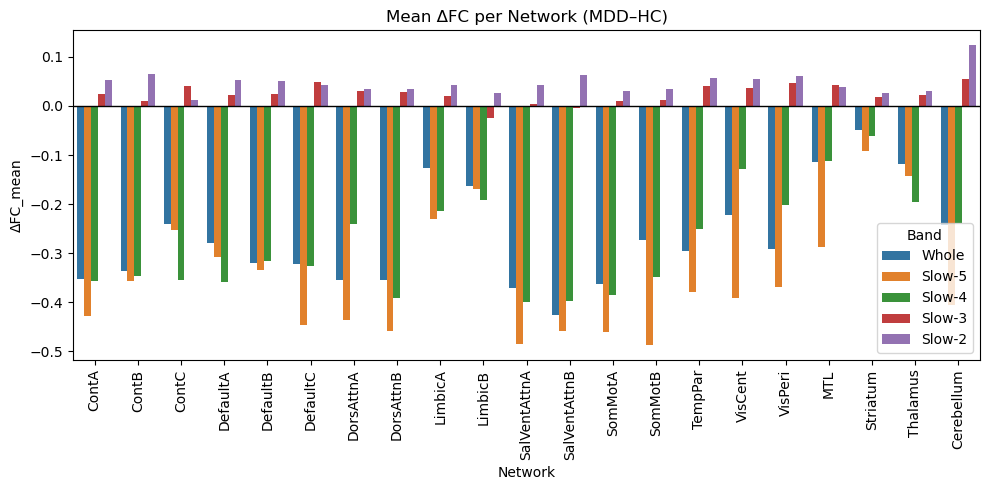

In [6]:
summary = []
for band, subj_fcs in z_binned_netfcs.items():
    subs = list(subj_fcs.keys())
    group_labels = [groups[s] for s in subs]
    mdd = np.array([subj_fcs[s] for s, g in zip(subs, group_labels) if g == "MDD"])
    hc  = np.array([subj_fcs[s] for s, g in zip(subs, group_labels) if g == "HC"])
    
    diff_mat = np.nanmean(mdd, axis=0) - np.nanmean(hc, axis=0)

    # Exclude self-connections
    diff_mat_no_diag = diff_mat.copy()
    np.fill_diagonal(diff_mat_no_diag, np.nan)

    mean_dfc = np.nanmean(diff_mat_no_diag, axis=1)
    
    df_band = pd.DataFrame({
        "Network": net_names_21,
        "ΔFC_mean": mean_dfc,
        "Band": band
    })
    summary.append(df_band)

summary_df = pd.concat(summary)

# plot per band
plt.figure(figsize=(10,5))
sns.barplot(data=summary_df, x="Network", y="ΔFC_mean", hue="Band")
plt.axhline(0, color='k', lw=1)
plt.xticks(rotation=90)
plt.title("Mean ΔFC per Network (MDD–HC)")
plt.tight_layout()
plt.show()

### Statistical analysis: Are slow bands more sensitive to group differences?

In [7]:
### Network level test
bands_to_test = ["Slow-5", "Slow-4", "Slow-3", "Slow-2"]
net_results = []
for b in bands_to_test:
    res = compare_band_to_whole_network(summary_df, band=b, n_perm=5000, random_state=42, alternative="greater")
    net_results.append(res)

# example: list of p-values from all tested bands
pvals = [res["p_perm"] for res in net_results]
bands = [res["band"] for res in net_results]

_, pvals_fdr = multipletests(pvals, method="fdr_bh")[:2]

for band, p, pfdr in zip(bands, pvals, pvals_fdr):
    # print results, p corrected
    print(f"{band:>7} p = {p:.4f},  p_FDR = {pfdr:.4f}, Cohen's d = {net_results[bands.index(band)]['cohen_d']:.4f}, Hedges' g = {net_results[bands.index(band)]['hedges_g']:.4f}")

 Slow-5 p = 0.0002,  p_FDR = 0.0008, Cohen's d = 1.3921, Hedges' g = 1.3364
 Slow-4 p = 0.2507,  p_FDR = 0.5015, Cohen's d = 0.1536, Hedges' g = 0.1475
 Slow-3 p = 1.0000,  p_FDR = 1.0000, Cohen's d = -2.2553, Hedges' g = -2.1651
 Slow-2 p = 1.0000,  p_FDR = 1.0000, Cohen's d = -2.2266, Hedges' g = -2.1375


### Network level analysis

In [8]:
strength = compute_network_strength_df(z_binned_netfcs, groups, net_names_21)
net_level_results = test_network_level(strength, n_perm=20000, seed=42)


In [9]:
print_network_overview(net_level_results)


BAND: Slow-2
SalVentAttnB    Δ=+0.063 | d=+0.614 | p=0.8431 | q=0.8431 | ↑ MDD
ContB           Δ=+0.065 | d=+0.604 | p=0.8311 | q=0.8431 | ↑ MDD
LimbicA         Δ=+0.043 | d=+0.542 | p=0.8184 | q=0.8431 | ↑ MDD
DefaultB        Δ=+0.050 | d=+0.514 | p=0.8031 | q=0.8431 | ↑ MDD
ContA           Δ=+0.054 | d=+0.493 | p=0.7849 | q=0.8431 | ↑ MDD
TempPar         Δ=+0.057 | d=+0.486 | p=0.7823 | q=0.8431 | ↑ MDD
LimbicB         Δ=+0.026 | d=+0.481 | p=0.7490 | q=0.8431 | ↑ MDD
DefaultA        Δ=+0.054 | d=+0.474 | p=0.7790 | q=0.8431 | ↑ MDD
Cerebellum      Δ=+0.124 | d=+0.452 | p=0.7378 | q=0.8431 | ↑ MDD
SalVentAttnA    Δ=+0.043 | d=+0.398 | p=0.7482 | q=0.8431 | ↑ MDD
MTL             Δ=+0.039 | d=+0.397 | p=0.7464 | q=0.8431 | ↑ MDD
Striatum        Δ=+0.026 | d=+0.382 | p=0.7409 | q=0.8431 | ↑ MDD
DefaultC        Δ=+0.043 | d=+0.367 | p=0.7062 | q=0.8431 | ↑ MDD
SomMotB         Δ=+0.034 | d=+0.328 | p=0.7082 | q=0.8431 | ↑ MDD
VisPeri         Δ=+0.062 | d=+0.308 | p=0.6501 | q=0.8431 | ↑ 

### More analysis: Which specific networks contributed the most to that increase?

In [10]:
### Networks where Slow-5 adds the most group-difference signal compared to wholeband.
drivers_slow5 = compute_slow_network_drivers(summary_df, band_label="Slow-5")

# Look at top 10 networks driving the Slow-5 > Whole difference
print(drivers_slow5[["Network",
                     "ΔFC_mean_Whole",
                     "ΔFC_mean_Slow-5",
                     "abs_whole",
                     "abs_band",
                     "d_abs",
                     "dir_Whole",
                     "dir_Slow"]].head(21))


         Network  ΔFC_mean_Whole  ΔFC_mean_Slow-5  abs_whole  abs_band  \
0        SomMotB       -0.272589        -0.486376   0.272589  0.486376   
1            MTL       -0.113577        -0.287135   0.113577  0.287135   
2        VisCent       -0.221633        -0.391246   0.221633  0.391246   
3     Cerebellum       -0.242270        -0.405079   0.242270  0.405079   
4       DefaultC       -0.321318        -0.445703   0.321318  0.445703   
5   SalVentAttnA       -0.371045        -0.485272   0.371045  0.485272   
6      DorsAttnB       -0.355112        -0.459147   0.355112  0.459147   
7        LimbicA       -0.127009        -0.229326   0.127009  0.229326   
8        SomMotA       -0.362587        -0.459643   0.362587  0.459643   
9        TempPar       -0.295810        -0.378299   0.295810  0.378299   
10     DorsAttnA       -0.354982        -0.435791   0.354982  0.435791   
11       VisPeri       -0.291382        -0.369573   0.291382  0.369573   
12         ContA       -0.352005      

      Connection       ΔFC    Band
0       DefaultC -0.434031  Slow-5
1        TempPar -0.414725  Slow-5
2      DorsAttnA -0.413666  Slow-5
3       DefaultB -0.408627  Slow-5
4        SomMotB -0.400231  Slow-5
5            MTL -0.392276  Slow-5
6      DorsAttnB -0.364568  Slow-5
7     Cerebellum -0.258065  Slow-5
8          ContA -0.208811  Slow-5
9        VisCent -0.148766  Slow-5
10  SalVentAttnA -0.147602  Slow-5
11  SalVentAttnB -0.138743  Slow-5
12       SomMotA -0.138530  Slow-5
13      DefaultA -0.131224  Slow-5
14       VisPeri -0.127737  Slow-5
15         ContB -0.124703  Slow-5
16       LimbicB -0.107797  Slow-5
17         ContC -0.105329  Slow-5
18      Striatum -0.062648  Slow-5
19      Thalamus -0.058445  Slow-5


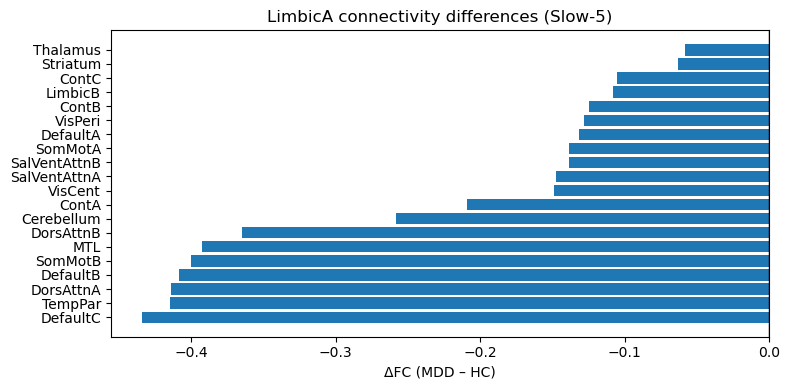

In [11]:
seed = "LimbicA"
band = "Slow-5"
limbica_slow_edges = get_network_edges(results_band, seed_network=seed, band_label=band)

print(limbica_slow_edges)
plot_network_edges(limbica_slow_edges, seed_network=seed, band_label=band)